## Coding Homework 1 - Chapter 2 - CLRS

### Double-click the cell to add your name here

### 1-25-2026

<mark>___________________________________________________________________________________________________________</mark>

## Lab Description

The purpose of this coding homework is to get our hands on implementing algorithms of different types we have been analyzing in the paper homework.


**Tasks to complete**
### 1. Implement the ADD-BINARY-INTEGERS algorithm from exercise 2.1-5 of the textbook.
    * see the description in the textbook
    * you must implement add_binary_integers(A,B)
    * you should also implement binary_to_decimal(X) to convert array X to decimal form
        * you can use this to check your code more easily
### 2. Implement the SELECTION-SORT algorithm from excercise 2.2-2 of the textbook.
    * see the description in the textbook
    * you method must work "in-place" meaning only using the initial memory you were given and a constant ammount of additional memory
### 3. Implement the COURSE-MERGE-SORT algorithm from problem 2-1 in the textbook.
    * see page 45 of the textbook (end of chapter 2 problems)
    * you should make use of the code provided for insertion sort and merge sort from lecture
    * test your code for different coarsening parameters k
### 4. Implement the BUBBLE-SORT algorithm from problem 2-2 in the textbook.
    * see page 46 of the textbook (end of chapter 2 problems)
    * Demonstrate that your algorithms follow the two loop invariants discussed in the textbook by adding appropriate print statements to the code.
### 5. Implement the polynomial evaluation tool HORNER from problem 2.3 in the textbook.
    * see page page 47 of the textbook (end of chapter 2 problems) for the pseudo code
    * You should also implement the code for a generic polynomial evaluator as discussed in Problem 2.3 b.
    * Test your two methods with the test code provided.

<mark>___________________________________________________________________________________________________________</mark>

<mark>___________________________________________________________________________________________________________</mark>

## Problems

### 1. Implement the ADD-BINARY-INTEGERS algorithm from exercise 2.1-5 of the textbook.

Consider the problem of adding two $n$-bit binary integers $a$ and $b$, stored in two $n$-element arrays $A[0 : n - 1]$ and $B[0 : n - 1]$, where each element is either $0$ or $1$, $$a=\sum_{i=0}^{n-1}A[i]x^i,$$ and $$b=\sum_{i=0}^{n-1}B[i]x^i.$$ The sum $c = a + b$ of the two integers should be stored in binary form in an $(n + 1)$-element array $C [0 : n]$, where $$c=\sum_{i=0}^{n}C[i]x^i.$$

Implement a procedure ADD-BINARY-INTEGERS below that takes as input arrays $A$ and $B$, along with the length $n$, and returns array $C$ holding the sum.

In [95]:
def add_binary_integers(A,B,n):
    """adds binary integers stored in A and B returning an array C"""

    ############################################
    # insert code here
    total = bin_to_dec(A) + bin_to_dec(B)
    
    C = []
    C.append(total)
    
    return C

In [96]:
def bin_to_dec(X):
    """returns the decimal value of the binary array"""
    val = 0
    for i in range(len(X)):
        val += X[i]*2**i
    return val

In [97]:
import random

n = 8
# generate random bits to add
A = [random.randrange(2) for i in range(8)]
print(A)
a = bin_to_dec(A)
print("a =",a)

B = [random.randrange(2) for i in range(8)]
print(B)
b = bin_to_dec(B)
print("b =",b)


# call the code
print("-"*50)
C = add_binary_integers(A,B,n)
print(C)
c = bin_to_dec(C)
print("a + b =",c)

# check the correctness of the binary addition code
if a+b==c: print("correct!")

[0, 0, 1, 1, 0, 0, 0, 0]
a = 12
[1, 0, 1, 0, 1, 1, 0, 1]
b = 181
--------------------------------------------------
[193]
a + b = 193
correct!


<mark>___________________________________________________________________________________________________________</mark>

### 2. Implement the SELECTION-SORT algorithm from excercise 2.2-2 of the textbook.

Consider sorting $n$ numbers stored in array $A[0 : n]$ by first finding the smallest element of A[0 : n] and exchanging it with the element in A[0]. Then find the smallest element of A[1 : n], and exchange it with A[1]. Then find the smallest element of A[2 : n], and exchange it with A[2]. Continue in this manner for the first $n - 1$ elements of $A$.

Implement this algorithm below, which is known as selection sort.

In [99]:
def selection_sort(A,n):
    """sorts the array A (in-place) using the selection sort algorithm"""

    ###############################################
    # insert code here

    curr_min = 0
    curr_item = 0
    curr_index = 0

    for i in range(n - 1):

        min_index = i

        for j in range(i + 1,n):
            if A[j] < A[min_index]:
                min_index = j

        
        tmp = A[i]
        A[i] = A[min_index]
        A[min_index] = tmp

    return A

In [100]:
def sameQ(A,B):
    """returns True if arrays A and B contain the same values"""
    
    m,n = len(A),len(B)     # compute lengths
    if m!=n: return False   # check if length is the same
    
    for i in range(n):      # loop over elements
        if A[i]!=B[i]: return False # check if they are the same
    
    return True

In [101]:
from time import time
import random

n = 1000
N = n*n
A = [random.randrange(-N,N) for i in range(n)]
correct_sort = sorted(A)
#print(A)

################ selection sort ##############
start = time()
selection_sort(A,n)
stop = time()
print("selection:",stop-start)
if sameQ(A,correct_sort):
    print("correct!")

selection: 0.02060413360595703
correct!


<mark>___________________________________________________________________________________________________________</mark>

### 3. Implement the COURSE-MERGE-SORT algorithm from problem 2-1 in the textbook.

Although merge sort runs in $\Theta(n \log n)$ worst-case time and insertion sort runs in $\Theta(n^2)$ worst-case time, the constant factors in insertion sort can make it faster in practice for small problem sizes on many machines. Thus it makes sense to coarsen the leaves of the recursion by using insertion sort within merge sort when subproblems become sufficiently small.

Implement a modification to merge sort in which $n/k$ sublists of length $k$ are sorted using insertion sort and then merged using the standard merging mechanism, where $k$ is a value to be determined.

#### a. Insertion-Sort

In [102]:
def insertion_sort_python(A,n):
    """sorts the array A (in-place) using the insertion sort algorithm from CLRS-ch2"""
    
    for i in range(1,n):
        # (Loop Invariant)
        # the elements in positions 0 to i-1 are sorted (start at 1)
        #print(A[:i])
        
        key = A.pop(i)               # pop current element
        
        j = i-1
        while j>=0 and A[j]>key:    # walk back to find insertion point
            j = j-1                 # move back
        
        A.insert(j+1,key)           # insert ith element (key) into position j+1

    return A

#### b. Merge-Sort (list)

In [103]:
def merge_list(A,B):
    """merges lists A and B (assuming they are each in order)"""

    N = len(A)+len(B)
    output = [None for i in range(N)]   # space requirement O( |A| + |B| )

    k = N-1  # location to copy to
    while A and B:
        if A[-1] > B[-1]:               # load output from the back
            key = A.pop()               # remove from A
        else:
            key = B.pop()               # remove from B
        output[k] = key
        k-=1
    ######################## empty A or B when they are the only one left
    while A:
        key = A.pop()
        output[k] = key
        k-=1
    while B:
        key = B.pop()
        output[k] = key
        k-=1

    return output       # reference to new array with combined values

In [66]:
def merge_sort_list(A,n):
    """sorts the array A using the merge sort algorithm"""
    
    if n < 2:    # base case
        return A
    
    q = int(n/2) # split point
    L = merge_sort_list(A[:q],q)    # recursive case (left)
    R = merge_sort_list(A[q:],n-q)    # recursive case (right)
    
    return merge_list(L,R)           # combine partial solutions

In [104]:
def merge_coarse(A,n,k=8):
    """sorts the array A using the merge sort algorithm with insertion sort for leaf cases of size less than k"""
    
    ###########################################
    # insert code here
    if n < k:
        for i in range(1, n):
            key = A[i]
            j = i - 1
            while j >= 0 and A[j] > key:
                A[j + 1] = A[j]
                j -= 1
            A[j + 1] = key
        return A
    
    q = int(n / 2)
    L = merge_coarse(A[:q], q, k)
    R = merge_coarse(A[q:], n - q, k)
    
    return merge_list(L, R)


In [105]:
from time import time
import random

n = 10000
N = n*n
A = [random.randrange(-N,N) for i in range(n)]
A1 = [a for a in A]
A2 = [a for a in A]
A3 = [a for a in A]
A4 = [a for a in A]
correct_sort = sorted(A)
#print(A)

################ insertion sort (CLRS) ##############
start = time()
A1 = insertion_sort_python(A1,n)
stop = time()
print("insertion (CLRS):",stop-start)
if sameQ(A1,correct_sort):
    print("correct!")

################ insertion sort (python/Joy) ##############
start = time()
A2 = merge_sort_list(A2,n)
stop = time()
print("insertion (Joy):",stop-start)
if sameQ(A2,correct_sort):
    print("correct!")

################ merge sort ##############
start = time()
A3 = merge_coarse(A3,n)
stop = time()
print("merge sort:",stop-start)
if sameQ(A3,correct_sort):
    print("correct!")

################ merge sort ##############
start = time()
A4 = merge_coarse(A4,n,256)
stop = time()
print("merge sort:",stop-start)
if sameQ(A4,correct_sort):
    print("correct!")

insertion (CLRS): 0.6295590400695801
correct!
insertion (Joy): 0.013596057891845703
correct!
merge sort: 0.009865999221801758
correct!
merge sort: 0.01620006561279297
correct!


<mark>___________________________________________________________________________________________________________</mark>

### 4. Implement the BUBBLE-SORT algorithm from problem 2-2 in the textbook.

Bubblesort is a popular, but inefficient, sorting algorithm. It works by repeatedly swapping adjacent elements that are out of order. The procedure BUBBLE-SORT sorts array $A[1 : n]$.

<div style="width:50%; margin: auto;">
    
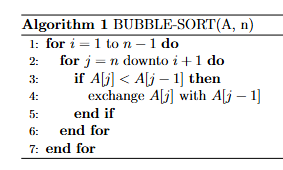

</div>

Implement the Bubble Sort algorithm above.

In [106]:
def bubble_sort(A,n):
    """sorts the array A (in-place) using the bubble sort algorithm"""

    ########################################
    # insert code here

    for i in range(n - 1):
        for j in range(1,n - i):
            if(A[j] < A[j-1]):
                tmp = A[j]
                A[j] = A[j-1]
                A[j-1] = tmp

    
    
    
    
    return A

In [107]:
from time import time
import random

n = 10000
N = n*n
A = [random.randrange(-N,N) for i in range(n)]
correct_sort = sorted(A)
#print(A)

################ selection sort ##############
start = time()
bubble_sort(A,n)
stop = time()
print("bubble sort:",stop-start)
if sameQ(A,correct_sort):
    print("correct!")

bubble sort: 2.4865801334381104
correct!


In [108]:
def bubble_sort_verbose(A,n):
    """sorts the array A (in-place) using the bubble sort algorithm (with prints of Loop Invariants)"""

    ########################################
    # insert code here
    
    # make sure to print both loop invariants (1 print for each loop)
    
    
    for i in range(n - 1):
        print(f"i = {i}, {i} is now sorted")
        for j in range(1,n - i):
            print(f"j = {j},   A[{j}]={A[j]}")
            if(A[j] < A[j-1]):
                tmp = A[j]
                A[j] = A[j-1]
                A[j-1] = tmp

    
    
    
    print(f"output: {A}")
    return A

In [109]:
import random

n = 8
A = [random.randrange(100) for i in range(n)]
print("before:",A)

# Call Method
bubble_sort_verbose(A,n)
print("after:",A)

before: [94, 7, 68, 82, 81, 63, 54, 61]
i = 0, 0 is now sorted
j = 1,   A[1]=7
j = 2,   A[2]=68
j = 3,   A[3]=82
j = 4,   A[4]=81
j = 5,   A[5]=63
j = 6,   A[6]=54
j = 7,   A[7]=61
i = 1, 1 is now sorted
j = 1,   A[1]=68
j = 2,   A[2]=82
j = 3,   A[3]=81
j = 4,   A[4]=63
j = 5,   A[5]=54
j = 6,   A[6]=61
i = 2, 2 is now sorted
j = 1,   A[1]=68
j = 2,   A[2]=81
j = 3,   A[3]=63
j = 4,   A[4]=54
j = 5,   A[5]=61
i = 3, 3 is now sorted
j = 1,   A[1]=68
j = 2,   A[2]=63
j = 3,   A[3]=54
j = 4,   A[4]=61
i = 4, 4 is now sorted
j = 1,   A[1]=63
j = 2,   A[2]=54
j = 3,   A[3]=61
i = 5, 5 is now sorted
j = 1,   A[1]=54
j = 2,   A[2]=61
i = 6, 6 is now sorted
j = 1,   A[1]=54
output: [7, 54, 61, 63, 68, 81, 82, 94]
after: [7, 54, 61, 63, 68, 81, 82, 94]


<mark>___________________________________________________________________________________________________________</mark>

### 5. Implement the polynomial evaluation tool HORNER from problem 2.3 in the textbook.

Consider the evaluation of a polynomial $P(x) = a_0 + a_1x + a_2x^2  + \ldots + a_{n-1}x^{n-1} + a_nx^n$ for a given value of $x$.

*Horner’s rule* says to evaluate the polynomial as below:
$$
P(x) = a_0 + x(a_1 + x(a_2 + \ldots + x(a_{n-1}+xa_n)\ldots))
$$
Implement the procedure HORNER(A,n,x) below to evaluate $P(x)$, given the coefficient array $A[0 : n]$ and the value of $x$.

<div style="width:50%; margin: auto;">
    
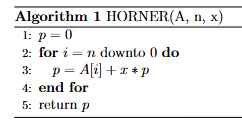

</div>

In [110]:
def horner(A,n,x):
    """evaluates the Horner form of the polynomial with coefficients in A"""

    ############################################
    # insert your code here
    p = 0

    for i in range(n-1,-1,-1):
        p = A[i] + (x * p)
    

    return p

In [111]:
def evaluate(A,n,x):
    """evaluates the polynomial with coefficients in A (the slow way)"""

    ############################################
    # insert your code here
    p = 0
    for i in range(n):
        p += A[i] * (x**i)




    

    # (HINT) you should use x**k for power k
    # or use a loop to compute the kth power your self (this is the slowest)

    
    return p

In [112]:
from time import time
import random

n = 10 # degree of polynomial
A = [random.random() for i in range(n+1)] # coefficients for polynomial p(x)

N = 1000000 # number of test points
X = [random.random() for i in range(N)]   # evaluation points 


################### Horner's Rule #####################
start = time()
for x in X:            # run code lots of times
    p = horner(A,n,x)
stop = time()
print("P(x) =",p)
print("computation time:",stop-start)


################### Generic Code ######################
start = time()
for x in X:           # run code lots of times
    p = evaluate(A,n,x)
stop = time()
print("P(x) =",p)
print("computation time:",stop-start)

P(x) = 0.8336754440060501
computation time: 0.38030171394348145
P(x) = 0.8336754440060499
computation time: 0.5868988037109375
